# Food-waste anaerobic digestion and biomethane-to-grid with NeqSim

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/bioprocesses/bioandneqsim.ipynb)

This tutorial develops a reproducible process study from wet organic feed to grid-quality
biomethane. It is intended for process engineers, environmental engineers, graduate students,
and analysts who want to connect biological conversion assumptions with thermodynamic streams,
gas upgrading, compression, and sustainability indicators.

All displayed process quantities use SI-derived engineering units. Normal gas volumes use
Nm³ at the reference conditions embedded in the NeqSim bioprocess models.

## Prerequisites and learning objectives

You should be comfortable with material balances, gas composition, and basic Python. No prior
NeqSim experience is required.

By the end, you will be able to:

1. represent a wet organic feed as a NeqSim thermodynamic stream;
2. configure substrate conversion in `AnaerobicDigester`;
3. verify methane production, organic loading rate, and hydraulic retention time;
4. compare water scrubbing, amine scrubbing, PSA, and membrane upgrading;
5. check mass closure around a NeqSim gas upgrader;
6. assemble and evaluate the `BiogasToGridModule`;
7. quantify grid-pressure energy demand and methane-slip sensitivity; and
8. recognize the validity limits of screening-level bioprocess models.

## 1. Colab-compatible setup

The setup installs the current public `neqsim` package only when it is absent. A hosted Colab
runtime can execute the notebook from top to bottom without a runtime restart.

In [1]:
import importlib.util
import subprocess
import sys


required_packages = ["neqsim", "pandas", "matplotlib"]
missing_packages = []

for package_name in required_packages:
    if importlib.util.find_spec(package_name) is None:
        missing_packages.append(package_name)

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            *missing_packages,
        ]
    )

print("Runtime dependencies are available.")

Runtime dependencies are available.


## 2. Imports, runtime, and NeqSim classes

NeqSim exposes its Java process and thermodynamic classes to Python. The notebook uses an SRK
thermodynamic system for fluid streams, an empirical anaerobic-digestion reactor, a physical gas
upgrader, a reusable gas-to-grid process module, and a sustainability-metrics calculator.

In [2]:
import importlib.metadata
import json
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jpype
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from neqsim import jneqsim


neqsim_version = importlib.metadata.version("neqsim")
python_version = platform.python_version()
JavaSystem = jpype.JClass("java.lang.System")
java_version = str(JavaSystem.getProperty("java.version"))

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [neqsim_version, python_version, java_version],
    }
)
print(runtime_table.to_string(index=False))

Runtime Version
 NeqSim  3.16.0
 Python 3.12.13
   Java 17.0.19


In [3]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
AnaerobicDigester = jneqsim.process.equipment.reactor.AnaerobicDigester
BiogasUpgrader = jneqsim.process.equipment.splitter.BiogasUpgrader
BiogasToGridModule = (
    jneqsim.process.processmodel.biorefinery.BiogasToGridModule
)
SustainabilityMetrics = (
    jneqsim.process.util.fielddevelopment.SustainabilityMetrics
)

api_capabilities = {
    "Thermodynamic fluid": SystemSrkEos,
    "Process stream": Stream,
    "Biological conversion": AnaerobicDigester,
    "Gas upgrading": BiogasUpgrader,
    "Integrated process module": BiogasToGridModule,
    "Sustainability calculation": SustainabilityMetrics,
}

print("NeqSim capabilities used in this workflow:")
for capability_name in api_capabilities:
    print(f"- {capability_name}")

NeqSim capabilities used in this workflow:
- Thermodynamic fluid
- Process stream
- Biological conversion
- Gas upgrading
- Integrated process module
- Sustainability calculation


## 3. Model and solver workflow

The wet-feed stream stores temperature, pressure, flow, and a thermodynamic fluid. The digester
combines that stream with substrate-specific methane-yield and volatile-solids parameters. Its
gas outlet becomes the inlet to an upgrading unit. The integrated module then composes digestion,
upgrading, compression, and cooling into one calculation.

The workflow is sequential: configure objects, call `run()`, retrieve results, check balances,
and repeat with changed inputs. This explicit lifecycle avoids hidden state between scenarios.

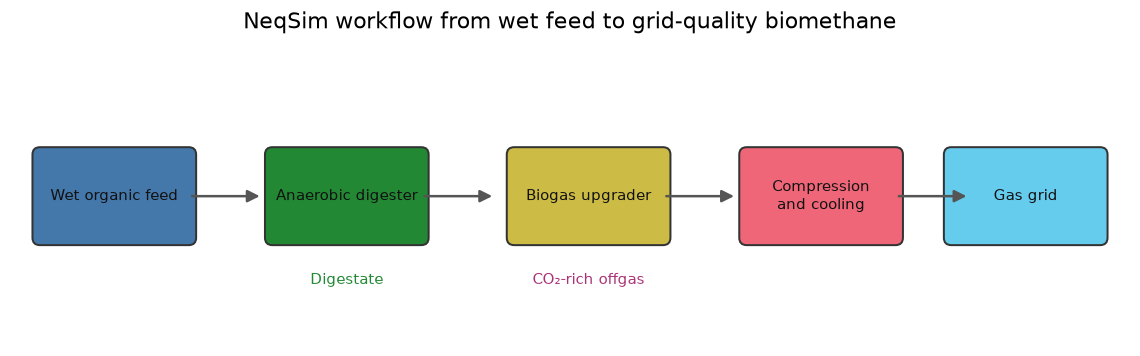

In [4]:
figure, axis = plt.subplots(figsize=(12.0, 3.2))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 3.2)
axis.axis("off")

box_specs = [
    (0.3, "Wet organic feed", "#4477AA"),
    (2.8, "Anaerobic digester", "#228833"),
    (5.4, "Biogas upgrader", "#CCBB44"),
    (7.9, "Compression\nand cooling", "#EE6677"),
    (10.1, "Gas grid", "#66CCEE"),
]

for x_position, label, color in box_specs:
    process_box = FancyBboxPatch(
        (x_position, 1.15),
        1.6,
        0.9,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.2,
    )
    axis.add_patch(process_box)
    axis.text(
        x_position + 0.8,
        1.60,
        label,
        ha="center",
        va="center",
        fontsize=9,
        color="#111111",
        wrap=True,
    )

for start_x in [1.9, 4.4, 7.0, 9.5]:
    arrow = FancyArrowPatch(
        (start_x, 1.60),
        (start_x + 0.8, 1.60),
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=1.5,
        color="#555555",
    )
    axis.add_patch(arrow)

axis.text(3.6, 0.65, "Digestate", ha="center", fontsize=9, color="#228833")
axis.text(6.2, 0.65, "CO₂-rich offgas", ha="center", fontsize=9, color="#AA3377")
axis.set_title(
    "NeqSim workflow from wet feed to grid-quality biomethane",
    fontsize=13,
    pad=12,
)
plt.show()

**Engineering interpretation.** The diagram highlights two different model layers. The
digester converts feed descriptors into biogas production using empirical substrate parameters.
The gas-upgrading and compression sections operate on NeqSim thermodynamic streams, so gas
composition, pressure, mass flow, and equipment energy are propagated through connected objects.

## 4. Governing digestion relationships

The volatile-solids flow is estimated from wet-feed flow, total-solids fraction, and the
volatile-solids-to-total-solids ratio:

$$
\dot{m}_{VS} = \dot{m}_{wet} x_{TS} x_{VS/TS}
$$

Methane production follows from the destroyed fraction and the substrate-specific methane yield:

$$
\dot{V}_{CH_4,N} = \dot{m}_{VS} X_{VS} Y_{CH_4}
$$

Here, $\dot{m}_{wet}$ is wet feed in kg/day, $x_{TS}$ is total-solids mass fraction,
$x_{VS/TS}$ is volatile solids per total solids, $X_{VS}$ is the destroyed volatile-solids
fraction, and $Y_{CH_4}$ is Nm³ CH₄ per kg VS destroyed.

Two design indicators connect feed rate to reactor volume:

$$
OLR = \frac{\dot{m}_{VS}}{V_R}
$$

$$
HRT = \frac{V_R}{\dot{V}_{feed}}
$$

`OLR` is organic loading in kg VS/(m³ day), $V_R$ is active reactor volume in m³, `HRT` is
hydraulic retention time in days, and $\dot{V}_{feed}$ is wet-feed volume in m³/day. The screening
calculation uses 1000 kg/m³ for wet-feed density when estimating feed volume.

## 5. Define a reproducible wet-feed stream

The thermodynamic stream is an aqueous organic-feed proxy at 35 °C and atmospheric pressure.
Solids conversion is specified separately in the digester because the empirical biogas model
uses wet feed, total solids, and substrate type directly. This separation is useful for early
design, but it is not a kinetic or aqueous-speciation model.

In [5]:
WET_FEED_KG_PER_HOUR = 5000.0
TOTAL_SOLIDS_FRACTION = 0.20
DIGESTER_VOLUME_M3 = 5000.0
DIGESTER_TEMPERATURE_C = 37.0
FEED_TEMPERATURE_C = 35.0
FEED_PRESSURE_BARA = 1.01325


def create_organic_feed(flow_rate_kg_per_hour=WET_FEED_KG_PER_HOUR):
    feed_fluid = SystemSrkEos(308.15, FEED_PRESSURE_BARA)
    feed_fluid.addComponent("water", 75.0)
    feed_fluid.addComponent("methane", 0.01)
    feed_fluid.setMixingRule("classic")

    feed_stream = Stream("wet organic feed", feed_fluid)
    feed_stream.setFlowRate(flow_rate_kg_per_hour, "kg/hr")
    feed_stream.setTemperature(FEED_TEMPERATURE_C, "C")
    feed_stream.setPressure(FEED_PRESSURE_BARA, "bara")
    feed_stream.run()
    return feed_stream

In [6]:
base_feed = create_organic_feed()

feed_summary = pd.DataFrame(
    {
        "Quantity": [
            "Wet-feed rate",
            "Feed temperature",
            "Feed pressure",
            "Total-solids fraction",
            "Active digester volume",
        ],
        "Value": [
            base_feed.getFlowRate("kg/hr"),
            base_feed.getTemperature("C"),
            base_feed.getPressure("bara"),
            TOTAL_SOLIDS_FRACTION,
            DIGESTER_VOLUME_M3,
        ],
        "Unit": ["kg/h", "°C", "bara", "kg TS/kg wet feed", "m³"],
    }
)

print(feed_summary.to_string(index=False))

              Quantity      Value              Unit
         Wet-feed rate 5000.00000              kg/h
      Feed temperature   35.00000                °C
         Feed pressure    1.01325              bara
 Total-solids fraction    0.20000 kg TS/kg wet feed
Active digester volume 5000.00000                m³


## 6. Configure and run the anaerobic digester

`AnaerobicDigester` selects calibrated screening parameters from its `SubstrateType` enumeration.
For food waste, the released model uses 0.92 kg VS/kg TS, 80% volatile-solids destruction, and
0.45 Nm³ CH₄/kg VS destroyed. The vessel volume controls `OLR` and `HRT`; substrate conversion
sets the gas-production potential.

In [7]:
def run_digester(
    substrate_type,
    wet_feed_kg_per_hour=WET_FEED_KG_PER_HOUR,
    total_solids_fraction=TOTAL_SOLIDS_FRACTION,
    vessel_volume_m3=DIGESTER_VOLUME_M3,
):
    feed_stream = create_organic_feed(wet_feed_kg_per_hour)
    digester = AnaerobicDigester("anaerobic digester", feed_stream)
    digester.setSubstrateType(substrate_type)
    digester.setDigesterTemperature(DIGESTER_TEMPERATURE_C, "C")
    digester.setFeedRate(
        wet_feed_kg_per_hour,
        total_solids_fraction,
    )
    digester.setVesselVolume(vessel_volume_m3)
    digester.run()
    return digester


base_digester = run_digester(
    AnaerobicDigester.SubstrateType.FOOD_WASTE
)

In [8]:
base_digester_results = pd.DataFrame(
    {
        "Quantity": [
            "Biogas production",
            "Methane production",
            "Methane content",
            "Organic loading rate",
            "Hydraulic retention time",
            "Volatile-solids destruction",
        ],
        "Value": [
            base_digester.getBiogasFlowRateNm3PerDay(),
            base_digester.getMethaneProductionNm3PerDay(),
            base_digester.getMethaneContentPercent(),
            base_digester.getOrganicLoadingRate(),
            base_digester.getHydraulicRetentionTimeDays(),
            base_digester.getActualVsDestruction() * 100.0,
        ],
        "Unit": [
            "Nm³/day",
            "Nm³ CH₄/day",
            "vol%",
            "kg VS/(m³ day)",
            "day",
            "%",
        ],
    }
)

print(base_digester_results.to_string(index=False, float_format="{:.4f}".format))

                   Quantity      Value           Unit
          Biogas production 13248.0000        Nm³/day
         Methane production  7948.8000    Nm³ CH₄/day
            Methane content    60.0000           vol%
       Organic loading rate     4.4160 kg VS/(m³ day)
   Hydraulic retention time    41.6667            day
Volatile-solids destruction    80.0000              %


The 5,000 kg/h food-waste case produces a methane-rich raw biogas. `OLR` and `HRT` should
be checked together: a vessel can satisfy a retention-time target while exceeding a biological
loading constraint, or vice versa. Project design limits depend on substrate degradability,
mixing, temperature, inhibitory compounds, and operating history.

## 7. Independent verification of digestion outputs

The following cell evaluates the governing equations independently from the NeqSim result
getters. Exact agreement demonstrates that the configured substrate parameters, time basis, and
reactor-volume basis are internally consistent.

In [9]:
food_waste = AnaerobicDigester.SubstrateType.FOOD_WASTE
wet_feed_kg_per_day = WET_FEED_KG_PER_HOUR * 24.0
vs_to_ts_ratio = food_waste.getVstsRatio()
vs_destruction = food_waste.getVsDestruction()
methane_yield = food_waste.getSpecificMethaneYield()

volatile_solids_kg_per_day = (
    wet_feed_kg_per_day
    * TOTAL_SOLIDS_FRACTION
    * vs_to_ts_ratio
)
expected_methane_nm3_per_day = (
    volatile_solids_kg_per_day
    * vs_destruction
    * methane_yield
)
expected_olr = volatile_solids_kg_per_day / DIGESTER_VOLUME_M3
feed_volume_m3_per_day = wet_feed_kg_per_day / 1000.0
expected_hrt = DIGESTER_VOLUME_M3 / feed_volume_m3_per_day

assert math.isclose(
    base_digester.getMethaneProductionNm3PerDay(),
    expected_methane_nm3_per_day,
    rel_tol=1.0e-10,
)
assert math.isclose(
    base_digester.getOrganicLoadingRate(),
    expected_olr,
    rel_tol=1.0e-10,
)
assert math.isclose(
    base_digester.getHydraulicRetentionTimeDays(),
    expected_hrt,
    rel_tol=1.0e-10,
)

print(f"Independent methane check: {expected_methane_nm3_per_day:.1f} Nm³/day")
print(f"Independent OLR check: {expected_olr:.3f} kg VS/(m³ day)")
print(f"Independent HRT check: {expected_hrt:.2f} day")

Independent methane check: 7948.8 Nm³/day
Independent OLR check: 4.416 kg VS/(m³ day)
Independent HRT check: 41.67 day


## 8. Substrate comparison

Substrate type changes volatile-solids content, destruction, and methane yield. All cases below
use the same wet-feed rate, total-solids fraction, vessel volume, and temperature, isolating the
effect of NeqSim's substrate descriptors.

In [10]:
substrate_types = [
    AnaerobicDigester.SubstrateType.SEWAGE_SLUDGE,
    AnaerobicDigester.SubstrateType.FOOD_WASTE,
    AnaerobicDigester.SubstrateType.MANURE,
    AnaerobicDigester.SubstrateType.CROP_RESIDUE,
    AnaerobicDigester.SubstrateType.ENERGY_CROP,
]
substrate_rows = []

for substrate_type in substrate_types:
    scenario_digester = run_digester(substrate_type)
    substrate_rows.append(
        {
            "Substrate": str(substrate_type).replace("_", " ").title(),
            "VS/TS (kg/kg)": substrate_type.getVstsRatio(),
            "VS destruction (%)": substrate_type.getVsDestruction() * 100.0,
            "CH4 yield (Nm3/kg VS destroyed)": (
                substrate_type.getSpecificMethaneYield()
            ),
            "Methane (Nm3/day)": (
                scenario_digester.getMethaneProductionNm3PerDay()
            ),
            "Biogas (Nm3/day)": scenario_digester.getBiogasFlowRateNm3PerDay(),
        }
    )

substrate_table = pd.DataFrame(substrate_rows)
print(substrate_table.to_string(index=False, float_format="{:.2f}".format))

    Substrate  VS/TS (kg/kg)  VS destruction (%)  CH4 yield (Nm3/kg VS destroyed)  Methane (Nm3/day)  Biogas (Nm3/day)
Sewage Sludge           0.70               55.00                             0.30            2772.00           4620.00
   Food Waste           0.92               80.00                             0.45            7948.80          13248.00
       Manure           0.80               45.00                             0.20            1728.00           2880.00
 Crop Residue           0.85               50.00                             0.28            2856.00           4760.00
  Energy Crop           0.90               65.00                             0.35            4914.00           8190.00


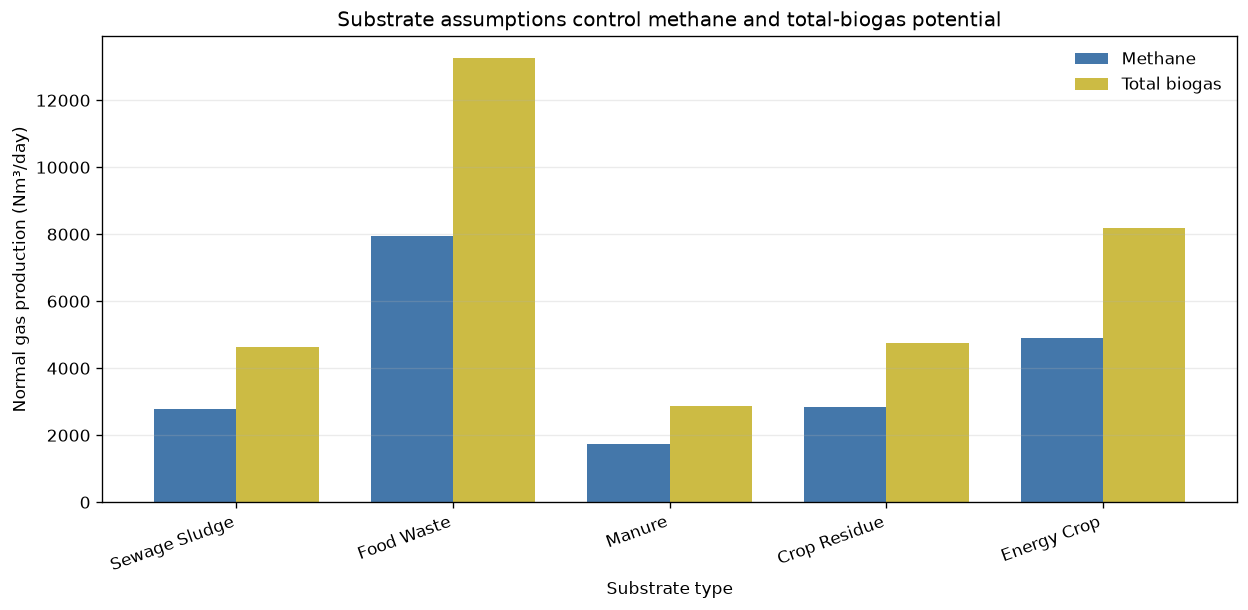

In [11]:
figure, axis = plt.subplots(figsize=(10.5, 5.2))
x_positions = np.arange(len(substrate_table))
bar_width = 0.38

axis.bar(
    x_positions - bar_width / 2.0,
    substrate_table["Methane (Nm3/day)"],
    width=bar_width,
    label="Methane",
    color="#4477AA",
)
axis.bar(
    x_positions + bar_width / 2.0,
    substrate_table["Biogas (Nm3/day)"],
    width=bar_width,
    label="Total biogas",
    color="#CCBB44",
)
axis.set_xticks(x_positions)
axis.set_xticklabels(substrate_table["Substrate"], rotation=20, ha="right")
axis.set_ylabel("Normal gas production (Nm³/day)")
axis.set_xlabel("Substrate type")
axis.set_title("Substrate assumptions control methane and total-biogas potential")
axis.grid(axis="y", alpha=0.25)
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

**Engineering interpretation.** Food waste has the highest methane potential in this
screening set because it combines high VS/TS, high destruction, and high specific methane yield.
This comparison is not a feedstock assay: site data from biochemical methane-potential testing
should replace default values before investment decisions.

## 9. Digester-volume sensitivity

At fixed feed and substrate properties, increasing active volume reduces organic loading and
increases hydraulic retention time. In this empirical potential model, methane production is
unchanged by volume; a real plant may lose conversion when retention time becomes too short.

In [12]:
vessel_volumes_m3 = np.array(
    [3000.0, 4000.0, 5000.0, 6000.0, 7500.0, 9000.0]
)
volume_rows = []

for vessel_volume_m3 in vessel_volumes_m3:
    volume_digester = run_digester(
        AnaerobicDigester.SubstrateType.FOOD_WASTE,
        vessel_volume_m3=vessel_volume_m3,
    )
    volume_rows.append(
        {
            "Volume (m3)": vessel_volume_m3,
            "OLR (kg VS/(m3 day))": volume_digester.getOrganicLoadingRate(),
            "HRT (day)": volume_digester.getHydraulicRetentionTimeDays(),
            "Methane (Nm3/day)": (
                volume_digester.getMethaneProductionNm3PerDay()
            ),
        }
    )

volume_table = pd.DataFrame(volume_rows)
print(volume_table.to_string(index=False, float_format="{:.3f}".format))

 Volume (m3)  OLR (kg VS/(m3 day))  HRT (day)  Methane (Nm3/day)
    3000.000                 7.360     25.000           7948.800
    4000.000                 5.520     33.333           7948.800
    5000.000                 4.416     41.667           7948.800
    6000.000                 3.680     50.000           7948.800
    7500.000                 2.944     62.500           7948.800
    9000.000                 2.453     75.000           7948.800


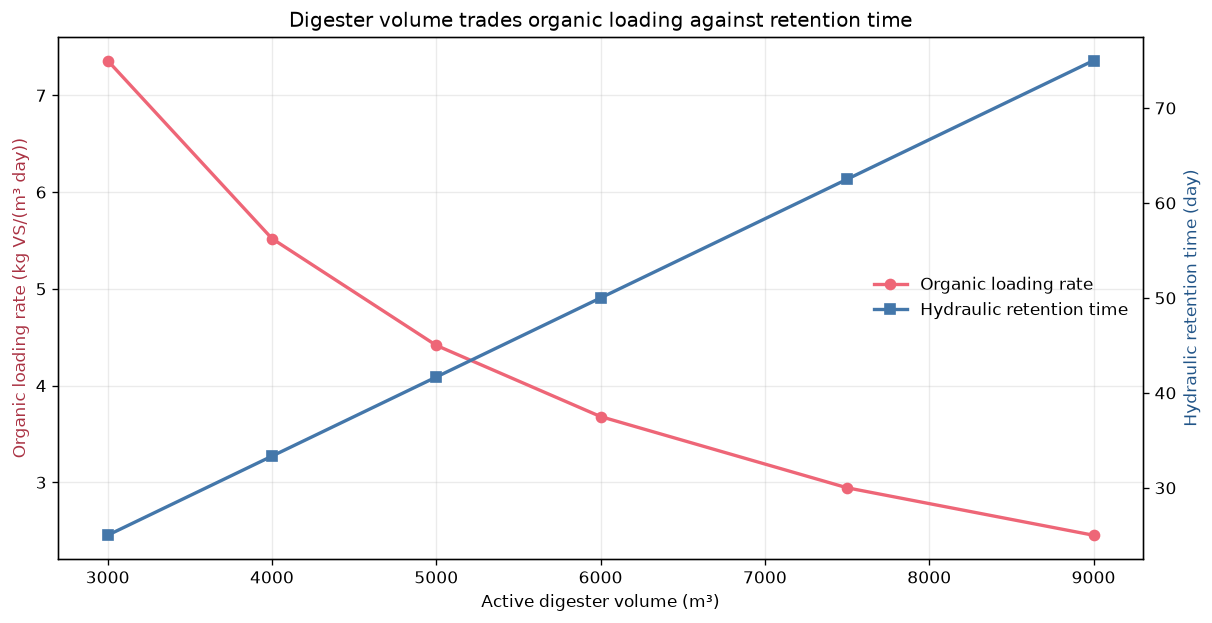

In [13]:
figure, loading_axis = plt.subplots(figsize=(10.2, 5.3))
retention_axis = loading_axis.twinx()

loading_axis.plot(
    volume_table["Volume (m3)"],
    volume_table["OLR (kg VS/(m3 day))"],
    marker="o",
    linewidth=2.0,
    color="#EE6677",
    label="Organic loading rate",
)
retention_axis.plot(
    volume_table["Volume (m3)"],
    volume_table["HRT (day)"],
    marker="s",
    linewidth=2.0,
    color="#4477AA",
    label="Hydraulic retention time",
)
loading_axis.set_xlabel("Active digester volume (m³)")
loading_axis.set_ylabel("Organic loading rate (kg VS/(m³ day))", color="#AA3344")
retention_axis.set_ylabel("Hydraulic retention time (day)", color="#225588")
loading_axis.set_title("Digester volume trades organic loading against retention time")
loading_axis.grid(alpha=0.25)

lines = loading_axis.get_lines() + retention_axis.get_lines()
labels = [line.get_label() for line in lines]
loading_axis.legend(lines, labels, loc="center right", frameon=False)
figure.tight_layout()
plt.show()

**Engineering interpretation.** The 5,000 m³ basis gives 4.416 kg VS/(m³ day) and
41.67 days HRT. This is a transparent screening point, not a universal optimum. Detailed design
must consider kinetics, mixing power, active versus gross volume, seasonal temperature, ammonia,
volatile fatty acids, foaming, and redundancy.

## 10. Biogas upgrading theory

The upgrader partitions the raw-biogas thermodynamic stream into biomethane and CO₂-rich offgas.
Its primary closure requirement is:

$$
\dot{m}_{raw} = \dot{m}_{biomethane} + \dot{m}_{offgas}
$$

Methane recovery is the fraction of inlet methane retained in the product:

$$
\eta_{CH_4} = \frac{\dot{n}_{CH_4,product}}{\dot{n}_{CH_4,feed}}
$$

Technology parameters represent screening-level recovery, CO₂ removal, methane slip, and energy
demand. Vendor performance guarantees and trace-contaminant removal remain separate checks.

In [14]:
def run_upgrader(technology, inlet_stream):
    upgrader = BiogasUpgrader(
        f"{str(technology).lower()} upgrader",
        inlet_stream,
    )
    upgrader.setTechnology(technology)
    upgrader.run()
    return upgrader


upgrading_technologies = [
    BiogasUpgrader.UpgradingTechnology.WATER_SCRUBBING,
    BiogasUpgrader.UpgradingTechnology.AMINE_SCRUBBING,
    BiogasUpgrader.UpgradingTechnology.PSA,
    BiogasUpgrader.UpgradingTechnology.MEMBRANE,
]

upgrader_rows = []
upgrader_objects = {}
raw_biogas_stream = base_digester.getBiogasOutStream()

for technology in upgrading_technologies:
    scenario_upgrader = run_upgrader(technology, raw_biogas_stream)
    technology_name = str(technology).replace("_", " ").title()
    upgrader_objects[technology_name] = scenario_upgrader
    upgrader_rows.append(
        {
            "Technology": technology_name,
            "CH4 product (vol%)": scenario_upgrader.getBiomethaneMethanePercent(),
            "CO2 product (vol%)": scenario_upgrader.getBiomethaneCO2Percent(),
            "CH4 recovery (%)": technology.getMethaneRecovery() * 100.0,
            "CO2 removal (%)": technology.getCo2RemovalEfficiency() * 100.0,
            "Methane slip (%)": scenario_upgrader.getMethaneSlipPercent(),
            "Power (kW)": scenario_upgrader.getEnergyConsumptionKW(),
            "Biomethane (Nm3/h)": (
                scenario_upgrader.getBiomethaneFlowNm3PerHr()
            ),
        }
    )

upgrader_table = pd.DataFrame(upgrader_rows)
print(upgrader_table.to_string(index=False, float_format="{:.3f}".format))

     Technology  CH4 product (vol%)  CO2 product (vol%)  CH4 recovery (%)  CO2 removal (%)  Methane slip (%)  Power (kW)  Biomethane (Nm3/h)
Water Scrubbing              97.746               1.995            98.000           97.000             2.000     159.382             332.061
Amine Scrubbing              99.089               0.661            99.900           99.000             0.100      79.691             333.911
            Psa              98.072               1.668            98.000           97.500             2.000     125.229             330.957
       Membrane              97.783               1.965            99.500           97.000             0.500     142.306             337.016


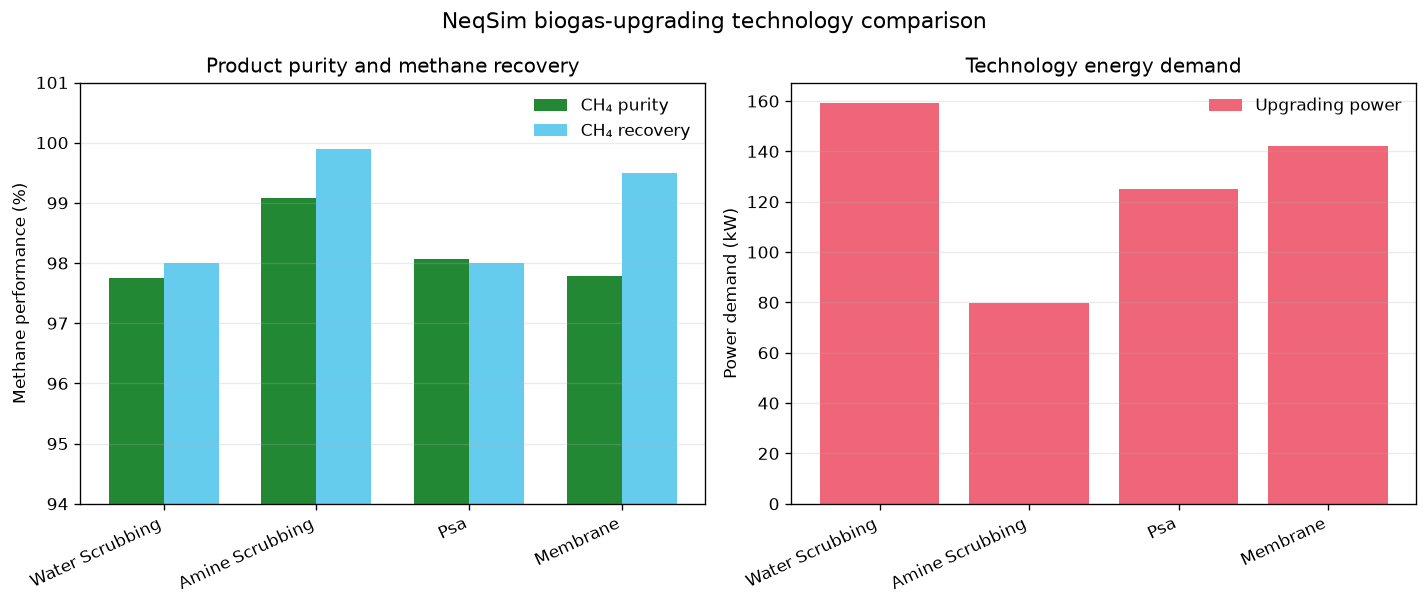

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 5.1))
x_positions = np.arange(len(upgrader_table))

axes[0].bar(
    x_positions - 0.18,
    upgrader_table["CH4 product (vol%)"],
    width=0.36,
    color="#228833",
    label="CH₄ purity",
)
axes[0].bar(
    x_positions + 0.18,
    upgrader_table["CH4 recovery (%)"],
    width=0.36,
    color="#66CCEE",
    label="CH₄ recovery",
)
axes[0].set_ylim(94.0, 101.0)
axes[0].set_ylabel("Methane performance (%)")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(upgrader_table["Technology"], rotation=25, ha="right")
axes[0].set_title("Product purity and methane recovery")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].bar(
    x_positions,
    upgrader_table["Power (kW)"],
    color="#EE6677",
    label="Upgrading power",
)
axes[1].set_ylabel("Power demand (kW)")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(upgrader_table["Technology"], rotation=25, ha="right")
axes[1].set_title("Technology energy demand")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False)

figure.suptitle("NeqSim biogas-upgrading technology comparison", fontsize=13)
figure.tight_layout()
plt.show()

**Engineering interpretation.** The model shows a purity, recovery, methane-slip, and
power trade-off. Amine scrubbing gives the highest purity and recovery for this case, while its
screening power demand is lowest. Technology selection must also include heat demand, chemicals,
water, turndown, maintenance, footprint, contaminants, and local product specifications.

In [16]:
upgrader_balance_rows = []

for technology_name, upgrader in upgrader_objects.items():
    inlet_mass_kg_per_hour = raw_biogas_stream.getFlowRate("kg/hr")
    biomethane_mass_kg_per_hour = (
        upgrader.getBiomethaneOutStream().getFlowRate("kg/hr")
    )
    offgas_mass_kg_per_hour = (
        upgrader.getOffgasOutStream().getFlowRate("kg/hr")
    )
    mass_residual_kg_per_hour = (
        inlet_mass_kg_per_hour
        - biomethane_mass_kg_per_hour
        - offgas_mass_kg_per_hour
    )
    relative_residual = abs(mass_residual_kg_per_hour) / inlet_mass_kg_per_hour

    assert relative_residual < 1.0e-10
    upgrader_balance_rows.append(
        {
            "Technology": technology_name,
            "Inlet (kg/h)": inlet_mass_kg_per_hour,
            "Products (kg/h)": (
                biomethane_mass_kg_per_hour + offgas_mass_kg_per_hour
            ),
            "Relative residual (-)": relative_residual,
        }
    )

upgrader_balance_table = pd.DataFrame(upgrader_balance_rows)
print(
    upgrader_balance_table.to_string(
        index=False,
        float_format="{:.6e}".format,
    )
)

     Technology  Inlet (kg/h)  Products (kg/h)  Relative residual (-)
Water Scrubbing  6.849180e+02     6.849180e+02           4.149651e-16
Amine Scrubbing  6.849180e+02     6.849180e+02           2.489791e-16
            Psa  6.849180e+02     6.849180e+02           4.979582e-16
       Membrane  6.849180e+02     6.849180e+02           4.149651e-16


## 11. Practical application: integrated biomethane-to-grid process

`BiogasToGridModule` composes the feed, digester, membrane upgrader, biomethane compressor, and
cooler. A module is useful when the same flowsheet must be evaluated repeatedly because its input
setters and result getters provide a stable engineering interface.

The scenario sends food-waste biomethane to a 25 °C gas grid. Grid pressure is varied while feed,
substrate, digester temperature, and upgrading technology remain fixed.

In [17]:
def run_biomethane_module(grid_pressure_bara):
    process_module = BiogasToGridModule(
        f"food-waste biomethane at {grid_pressure_bara:.0f} bara"
    )
    process_module.setFeedStream(create_organic_feed())
    process_module.setSubstrateType(
        AnaerobicDigester.SubstrateType.FOOD_WASTE
    )
    process_module.setUpgradingTechnology(
        BiogasUpgrader.UpgradingTechnology.MEMBRANE
    )
    process_module.setDigesterTemperatureC(DIGESTER_TEMPERATURE_C)
    process_module.setHydraulicRetentionTimeDays(30.0)
    process_module.setGridPressureBara(grid_pressure_bara)
    process_module.setGridTemperatureC(25.0)
    process_module.run()
    return process_module


grid_pressures_bara = [10.0, 20.0, 40.0, 60.0]
module_rows = []
module_objects = {}

for grid_pressure_bara in grid_pressures_bara:
    process_module = run_biomethane_module(grid_pressure_bara)
    module_objects[grid_pressure_bara] = process_module
    module_rows.append(
        {
            "Grid pressure (bara)": grid_pressure_bara,
            "Biomethane (Nm3/h)": (
                process_module.getBiomethaneFlowNm3PerHour()
            ),
            "Compressor power (kW)": process_module.getCompressorPowerKW(),
            "Cooler duty (kW)": process_module.getCoolerDutyKW(),
        }
    )

module_table = pd.DataFrame(module_rows)
print(module_table.to_string(index=False, float_format="{:.3f}".format))

 Grid pressure (bara)  Biomethane (Nm3/h)  Compressor power (kW)  Cooler duty (kW)
               10.000             311.970                 39.702            42.762
               20.000             311.970                 55.637            59.871
               40.000             311.970                 73.633            79.805
               60.000             311.970                 85.195            93.212


Compression intensity is reported on a normal-volume product basis:

$$
e_{comp} = \frac{P_{comp}}{\dot{V}_{biomethane,N}}
$$

Here, $e_{comp}$ is kWh/Nm³ when power is in kW and flow is in Nm³/h, $P_{comp}$ is compressor
power, and $\dot{V}_{biomethane,N}$ is normal biomethane flow.

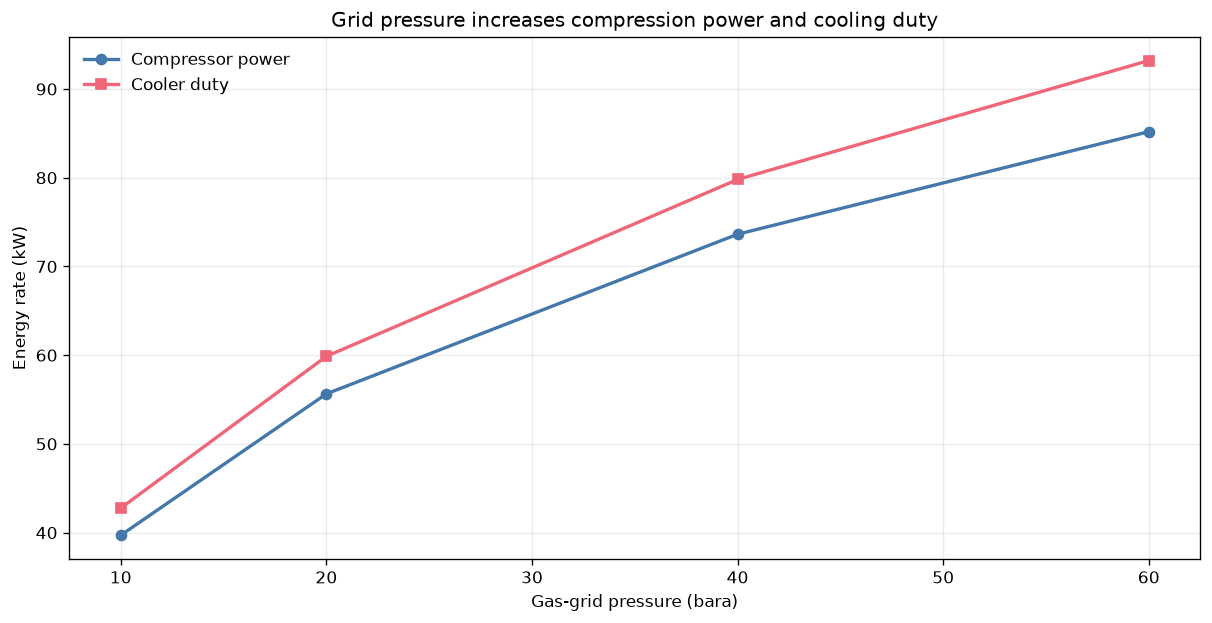

In [18]:
module_table["Compression intensity (kWh/Nm3)"] = (
    module_table["Compressor power (kW)"]
    / module_table["Biomethane (Nm3/h)"]
)

figure, energy_axis = plt.subplots(figsize=(10.2, 5.3))
energy_axis.plot(
    module_table["Grid pressure (bara)"],
    module_table["Compressor power (kW)"],
    marker="o",
    linewidth=2.0,
    color="#4477AA",
    label="Compressor power",
)
energy_axis.plot(
    module_table["Grid pressure (bara)"],
    module_table["Cooler duty (kW)"],
    marker="s",
    linewidth=2.0,
    color="#EE6677",
    label="Cooler duty",
)
energy_axis.set_xlabel("Gas-grid pressure (bara)")
energy_axis.set_ylabel("Energy rate (kW)")
energy_axis.set_title("Grid pressure increases compression power and cooling duty")
energy_axis.grid(alpha=0.25)
energy_axis.legend(frameon=False)
figure.tight_layout()
plt.show()

**Engineering interpretation.** Biomethane production remains constant because the
biological and upgrading inputs are unchanged. Raising grid pressure from 10 to 60 bara more than
doubles compressor power. Distribution-pressure injection can therefore have a materially lower
electricity demand than high-pressure transmission injection, subject to network capacity and
product specifications.

In [19]:
compressor_powers_kw = module_table["Compressor power (kW)"].to_numpy()
cooler_duties_kw = module_table["Cooler duty (kW)"].to_numpy()
biomethane_flows = module_table["Biomethane (Nm3/h)"].to_numpy()

assert np.all(np.diff(compressor_powers_kw) > 0.0)
assert np.all(np.diff(cooler_duties_kw) > 0.0)
assert np.allclose(
    biomethane_flows,
    biomethane_flows[0],
    rtol=1.0e-10,
)
assert np.all(np.isfinite(compressor_powers_kw))

base_module = module_objects[40.0]
module_json = json.loads(str(base_module.toJson()))

print("Integrated 40 bara process result:")
print(json.dumps(module_json, indent=2))

Integrated 40 bara process result:
{
  "moduleName": "food-waste biomethane at 40 bara",
  "processType": "Biogas-to-Grid",
  "gridPressure_bara": 40.0,
  "gridTemperature_C": 25.0,
  "upgradingTechnology": "MEMBRANE",
  "substrateType": "FOOD_WASTE",
  "biomethaneFlow_Nm3_per_hr": 311.96965567056316,
  "compressorPower_kW": 73.63280859074415,
  "coolerDuty_kW": 79.80485091804718,
  "hasRun": true
}


## 12. Sustainability and methane-slip sensitivity

The sustainability calculation converts process outputs and explicit boundary assumptions into
screening indicators. The example assumes 8,760 h/year operation, 50 kg CO₂/MWh imported
electricity, 30 km one-way feed transport, 60,000 kg N/year in digestate, and 2.0 kg CO₂/Nm³
displaced fossil gas. These are transparent scenario inputs, not universal life-cycle factors.

The reported net carbon balance is process emissions minus displaced fossil emissions:

$$
B_{net} = E_{process} - E_{displaced}
$$

A negative $B_{net}$ in t CO₂e/year indicates a modeled climate benefit within the stated
boundary. Methane slip is converted with the 100-year global-warming potential implemented by
NeqSim, so even a small volumetric loss can materially affect the result.

In [20]:
OPERATING_HOURS_PER_YEAR = 8760.0
GRID_FACTOR_KG_CO2_PER_KWH = 0.05
FEED_TRANSPORT_DISTANCE_KM = 30.0
FEED_TONNES_PER_YEAR = (
    WET_FEED_KG_PER_HOUR
    * OPERATING_HOURS_PER_YEAR
    / 1000.0
)
DIGESTATE_NITROGEN_KG_PER_YEAR = 60000.0
FOSSIL_GAS_FACTOR_KG_CO2_PER_NM3 = 2.0

annual_biogas_nm3 = (
    base_digester.getBiogasFlowRateNm3PerDay() * 365.0
)
annual_biomethane_nm3 = (
    base_module.getBiomethaneFlowNm3PerHour()
    * OPERATING_HOURS_PER_YEAR
)
annual_imported_electricity_mwh = (
    base_module.getCompressorPowerKW()
    * OPERATING_HOURS_PER_YEAR
    / 1000.0
)

In [21]:
def calculate_sustainability(methane_slip_percent):
    metrics = SustainabilityMetrics()
    metrics.setBiogasProductionNm3PerYear(annual_biogas_nm3)
    metrics.setMethaneContentFraction(
        base_digester.getMethaneContentPercent() / 100.0
    )
    metrics.setBiomethaneProductionNm3PerYear(annual_biomethane_nm3)
    metrics.setMethaneSlipPercent(methane_slip_percent)
    metrics.setImportedElectricityMWhPerYear(
        annual_imported_electricity_mwh
    )
    metrics.setGridElectricityEmissionFactor(
        GRID_FACTOR_KG_CO2_PER_KWH
    )
    metrics.setFeedstockTransport(
        FEED_TRANSPORT_DISTANCE_KM,
        FEED_TONNES_PER_YEAR,
    )
    metrics.setDigestateNitrogenKgPerYear(
        DIGESTATE_NITROGEN_KG_PER_YEAR
    )
    metrics.setN2OEmissionFraction(0.01)
    metrics.setFossilGasEmissionFactor(
        FOSSIL_GAS_FACTOR_KG_CO2_PER_NM3
    )
    metrics.calculate()
    return metrics


methane_slip_scenarios = [0.1, 0.5, 1.0, 2.0]
sustainability_rows = []

for methane_slip_percent in methane_slip_scenarios:
    metrics = calculate_sustainability(methane_slip_percent)
    sustainability_rows.append(
        {
            "Methane slip (%)": methane_slip_percent,
            "Emissions (t CO2e/year)": (
                metrics.getTotalEmissionsTCO2eqPerYear()
            ),
            "Net carbon balance (t CO2e/year)": (
                metrics.getNetCarbonBalanceTCO2PerYear()
            ),
            "Carbon intensity (kg CO2e/MWh)": (
                metrics.getCarbonIntensityKgCO2PerMWh()
            ),
            "EROI (-)": metrics.getEnergyReturnOnInvestment(),
        }
    )

sustainability_table = pd.DataFrame(sustainability_rows)
print(sustainability_table.to_string(index=False, float_format="{:.2f}".format))

 Methane slip (%)  Emissions (t CO2e/year)  Net carbon balance (t CO2e/year)  Carbon intensity (kg CO2e/MWh)  EROI (-)
             0.10                   511.21                          -4954.50                           18.76     42.24
             0.50                   745.68                          -4720.02                           27.37     42.24
             1.00                  1038.78                          -4426.93                           38.13     42.24
             2.00                  1624.97                          -3840.74                           59.64     42.24


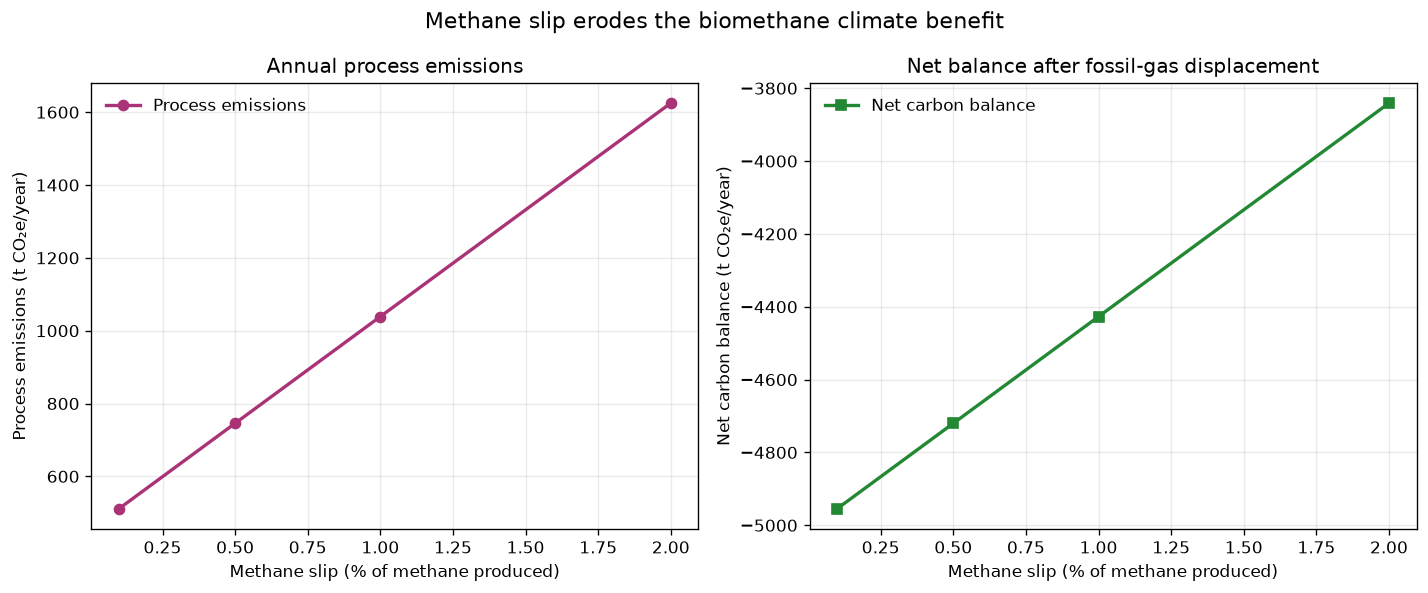

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))

axes[0].plot(
    sustainability_table["Methane slip (%)"],
    sustainability_table["Emissions (t CO2e/year)"],
    marker="o",
    linewidth=2.0,
    color="#AA3377",
    label="Process emissions",
)
axes[0].set_xlabel("Methane slip (% of methane produced)")
axes[0].set_ylabel("Process emissions (t CO₂e/year)")
axes[0].set_title("Annual process emissions")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(
    sustainability_table["Methane slip (%)"],
    sustainability_table["Net carbon balance (t CO2e/year)"],
    marker="s",
    linewidth=2.0,
    color="#228833",
    label="Net carbon balance",
)
axes[1].set_xlabel("Methane slip (% of methane produced)")
axes[1].set_ylabel("Net carbon balance (t CO₂e/year)")
axes[1].set_title("Net balance after fossil-gas displacement")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

figure.suptitle(
    "Methane slip erodes the biomethane climate benefit",
    fontsize=13,
)
figure.tight_layout()
plt.show()

**Engineering interpretation.** The modeled net balance remains negative across the
selected scenarios, but higher methane slip sharply increases total CO₂-equivalent emissions.
Leak detection, offgas treatment, reliable seals, and technology-specific performance guarantees
are therefore central design requirements, not secondary environmental details.

## 13. Consolidated design point

The following summary connects the biological, upgrading, compression, and sustainability layers
for the 40 bara membrane case. It is suitable as a template for project-specific inputs, criteria,
and scenario ranges.

In [23]:
base_sustainability = calculate_sustainability(0.5)
selected_membrane = upgrader_objects["Membrane"]

design_summary = pd.DataFrame(
    {
        "Design result": [
            "Raw biogas",
            "Digester methane",
            "Digester OLR",
            "Digester HRT",
            "Membrane methane purity",
            "Membrane methane recovery",
            "Grid biomethane",
            "Grid compressor power",
            "Grid cooler duty",
            "Net carbon balance at 0.5% slip",
        ],
        "Value": [
            base_digester.getBiogasFlowRateNm3PerDay(),
            base_digester.getMethaneProductionNm3PerDay(),
            base_digester.getOrganicLoadingRate(),
            base_digester.getHydraulicRetentionTimeDays(),
            selected_membrane.getBiomethaneMethanePercent(),
            (
                BiogasUpgrader.UpgradingTechnology.MEMBRANE
                .getMethaneRecovery()
                * 100.0
            ),
            base_module.getBiomethaneFlowNm3PerHour(),
            base_module.getCompressorPowerKW(),
            base_module.getCoolerDutyKW(),
            base_sustainability.getNetCarbonBalanceTCO2PerYear(),
        ],
        "Unit": [
            "Nm³/day",
            "Nm³ CH₄/day",
            "kg VS/(m³ day)",
            "day",
            "vol%",
            "%",
            "Nm³/h",
            "kW",
            "kW",
            "t CO₂e/year",
        ],
    }
)

print(design_summary.to_string(index=False, float_format="{:.3f}".format))

                  Design result     Value           Unit
                     Raw biogas 13248.000        Nm³/day
               Digester methane  7948.800    Nm³ CH₄/day
                   Digester OLR     4.416 kg VS/(m³ day)
                   Digester HRT    41.667            day
        Membrane methane purity    97.783           vol%
      Membrane methane recovery    99.500              %
                Grid biomethane   311.970          Nm³/h
          Grid compressor power    73.633             kW
               Grid cooler duty    79.805             kW
Net carbon balance at 0.5% slip -4720.025    t CO₂e/year


## 14. Verification checks

The final checks cover finite values, physical bounds, exact digestion equations, technology
behavior, upgrader mass closure, compression trends, and climate sensitivity. Assertions are
deliberately close to the engineering intent so future input changes fail informatively.

In [24]:
engineering_checks = {
    "positive biogas production": (
        base_digester.getBiogasFlowRateNm3PerDay() > 0.0
    ),
    "positive methane production": (
        base_digester.getMethaneProductionNm3PerDay() > 0.0
    ),
    "methane content within bounds": (
        0.0 < base_digester.getMethaneContentPercent() < 100.0
    ),
    "methane equation closes": math.isclose(
        base_digester.getMethaneProductionNm3PerDay(),
        expected_methane_nm3_per_day,
        rel_tol=1.0e-10,
    ),
    "OLR equation closes": math.isclose(
        base_digester.getOrganicLoadingRate(),
        expected_olr,
        rel_tol=1.0e-10,
    ),
    "HRT equation closes": math.isclose(
        base_digester.getHydraulicRetentionTimeDays(),
        expected_hrt,
        rel_tol=1.0e-10,
    ),
    "all substrate results finite": bool(
        np.isfinite(substrate_table.select_dtypes("number")).all().all()
    ),
    "food waste has highest methane in comparison": (
        substrate_table.loc[
            substrate_table["Substrate"] == "Food Waste",
            "Methane (Nm3/day)",
        ].iloc[0]
        == substrate_table["Methane (Nm3/day)"].max()
    ),
    "OLR decreases with vessel volume": bool(
        np.all(np.diff(volume_table["OLR (kg VS/(m3 day))"]) < 0.0)
    ),
    "HRT increases with vessel volume": bool(
        np.all(np.diff(volume_table["HRT (day)"]) > 0.0)
    ),
    "all upgrader purities exceed 95 vol%": bool(
        (upgrader_table["CH4 product (vol%)"] > 95.0).all()
    ),
    "all upgrader recoveries exceed 95 percent": bool(
        (upgrader_table["CH4 recovery (%)"] > 95.0).all()
    ),
    "upgrader balances close": bool(
        (
            upgrader_balance_table["Relative residual (-)"]
            < 1.0e-10
        ).all()
    ),
    "compressor power rises with grid pressure": bool(
        np.all(np.diff(compressor_powers_kw) > 0.0)
    ),
    "cooler duty rises with grid pressure": bool(
        np.all(np.diff(cooler_duties_kw) > 0.0)
    ),
    "grid biomethane flow is pressure independent": bool(
        np.allclose(biomethane_flows, biomethane_flows[0], rtol=1.0e-10)
    ),
    "module reports successful execution": bool(module_json["hasRun"]),
    "sustainability emissions rise with methane slip": bool(
        np.all(
            np.diff(
                sustainability_table["Emissions (t CO2e/year)"]
            )
            > 0.0
        )
    ),
    "net carbon balance worsens with methane slip": bool(
        np.all(
            np.diff(
                sustainability_table[
                    "Net carbon balance (t CO2e/year)"
                ]
            )
            > 0.0
        )
    ),
    "selected net carbon balance is beneficial": (
        base_sustainability.getNetCarbonBalanceTCO2PerYear() < 0.0
    ),
}

failed_checks = [
    check_name
    for check_name, check_passed in engineering_checks.items()
    if not check_passed
]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"

print(f"All {len(engineering_checks)} engineering checks passed.")
for check_name in engineering_checks:
    print(f"✓ {check_name}")

All 20 engineering checks passed.
✓ positive biogas production
✓ positive methane production
✓ methane content within bounds
✓ methane equation closes
✓ OLR equation closes
✓ HRT equation closes
✓ all substrate results finite
✓ food waste has highest methane in comparison
✓ OLR decreases with vessel volume
✓ HRT increases with vessel volume
✓ all upgrader purities exceed 95 vol%
✓ all upgrader recoveries exceed 95 percent
✓ upgrader balances close
✓ compressor power rises with grid pressure
✓ cooler duty rises with grid pressure
✓ grid biomethane flow is pressure independent
✓ module reports successful execution
✓ sustainability emissions rise with methane slip
✓ net carbon balance worsens with methane slip
✓ selected net carbon balance is beneficial


## 15. Assumptions, validity limits, and troubleshooting

**Assumptions and limits**

- Digestion uses substrate-specific empirical yields rather than microbial kinetics.
- Wet-feed density is approximated as 1000 kg/m³ for `HRT`.
- The thermodynamic feed is an aqueous proxy; solids, ionic chemistry, and inhibition are not
  explicitly flashed.
- Steady-state gas production does not represent startup, upset, foaming, or dynamic inventory.
- Upgrading parameters are screening values; gas-grid compliance also requires limits for water,
  oxygen, hydrogen sulfide, siloxanes, ammonia, heating value, and Wobbe index.
- The sustainability boundary excludes construction, avoided waste-treatment emissions, biogenic
  carbon accounting choices, and site-specific digestate credits.

**Troubleshooting**

- If Java does not start, restart with a clean Colab runtime and rerun from the setup cell.
- If a scenario returns implausible loading, confirm kg/h versus kg/day and fraction versus percent.
- Recreate each scenario object when changing technology or pressure to avoid unintended state
  carryover.
- If a product specification is not met, inspect both recovery and purity; increasing one does not
  guarantee the other.
- Replace default substrate parameters and emission factors with measured, documented project
  data before design decisions.

## 16. Summary

NeqSim can connect biological conversion assumptions to thermodynamic process streams and
equipment calculations in one Python workflow. For the stated 5,000 kg/h food-waste case:

- the analytical and NeqSim methane results agree at 7,948.8 Nm³ CH₄/day;
- the 5,000 m³ digester gives 4.416 kg VS/(m³ day) and 41.67 days HRT;
- all four upgrading technologies close their gas-stream mass balances;
- the integrated membrane process produces about 312 Nm³/h biomethane;
- 40 bara injection requires about 73.6 kW compression and 79.8 kW cooling; and
- methane-slip control materially improves the modeled carbon balance.

The reusable pattern is: define inputs, build fresh NeqSim objects, run, retrieve unit-aware
results, verify balances and trends, and then evaluate sensitivities.

## 17. Further exercises

1. Replace food waste with manure and resize the vessel to meet a chosen `HRT` and `OLR` window.
2. Add a product-gas acceptance table for methane, CO₂, pressure, and energy consumption.
3. Compare upgrading technologies at two feed rates and calculate kWh/Nm³ biomethane.
4. Add an avoided-waste-treatment credit as a clearly documented custom emission.
5. Use measured biochemical methane-potential data to define a project-specific substrate case.
6. Couple the biomethane outlet to storage, a transmission pipeline, or a downstream fuel process.

## References

- NeqSim documentation: [Bioprocessing](https://equinor.github.io/neqsimhome/)
- NeqSim source and examples: [equinor/neqsim](https://github.com/equinor/neqsim)
- International Energy Agency, *Outlook for Biogas and Biomethane*
- ISO 20675, *Biogas — Biogas production, conditioning, upgrading and utilization*
- VDI 4630, *Fermentation of organic materials*
- IPCC, *Sixth Assessment Report, Working Group I*, 100-year global-warming potentials

Use the edition and regulatory requirements applicable to the project location. Default values in
this notebook are illustrative engineering inputs and should be replaced by traceable project
data.